In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [2]:
DATA_PATH = "../data/train.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()

Shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
os.makedirs("../report/images", exist_ok=True)
print("Created report/images folder successfully.")

Created report/images folder successfully.


In [4]:
print("Số dòng:", df.shape[0])
print("Số cột:", df.shape[1])
print("Biến mục tiêu cần dự đoán: SalePrice")

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Số biến số:", len(numeric_cols))
print("Số biến phân loại:", len(categorical_cols))

Số dòng: 1460
Số cột: 81
Biến mục tiêu cần dự đoán: SalePrice
Số biến số: 38
Số biến phân loại: 43


C:\Users\Nguyen Ba Thao\AppData\Local\Temp\ipykernel_24176\1480533856.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns


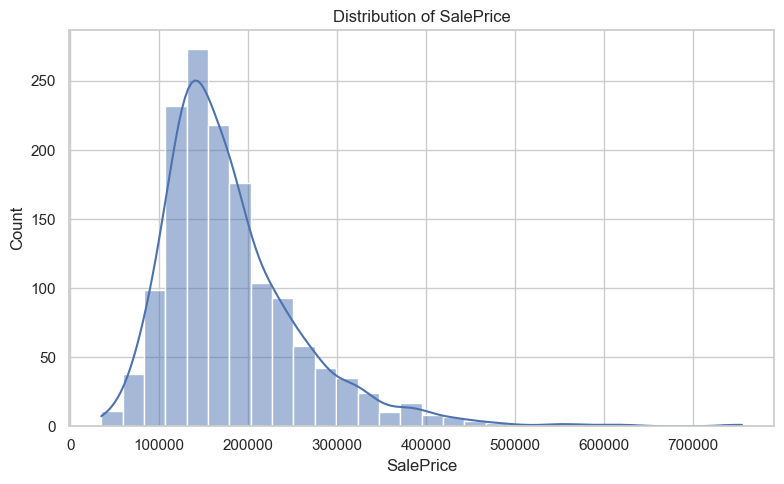

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(df["SalePrice"], kde=True, bins=30)
plt.title("Distribution of SalePrice")
plt.xlabel("SalePrice")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../report/images/fig01_saleprice_distribution.png", dpi=300)
plt.show()

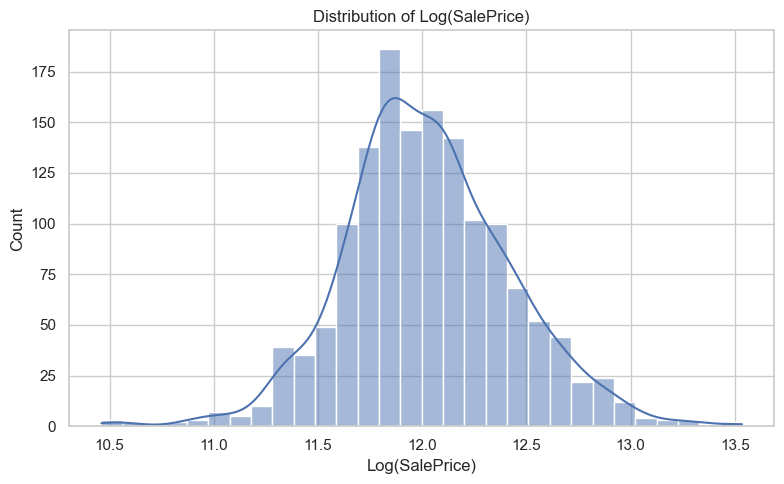

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(np.log1p(df["SalePrice"]), kde=True, bins=30)
plt.title("Distribution of Log(SalePrice)")
plt.xlabel("Log(SalePrice)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("../report/images/fig02_log_saleprice_distribution.png", dpi=300)
plt.show()

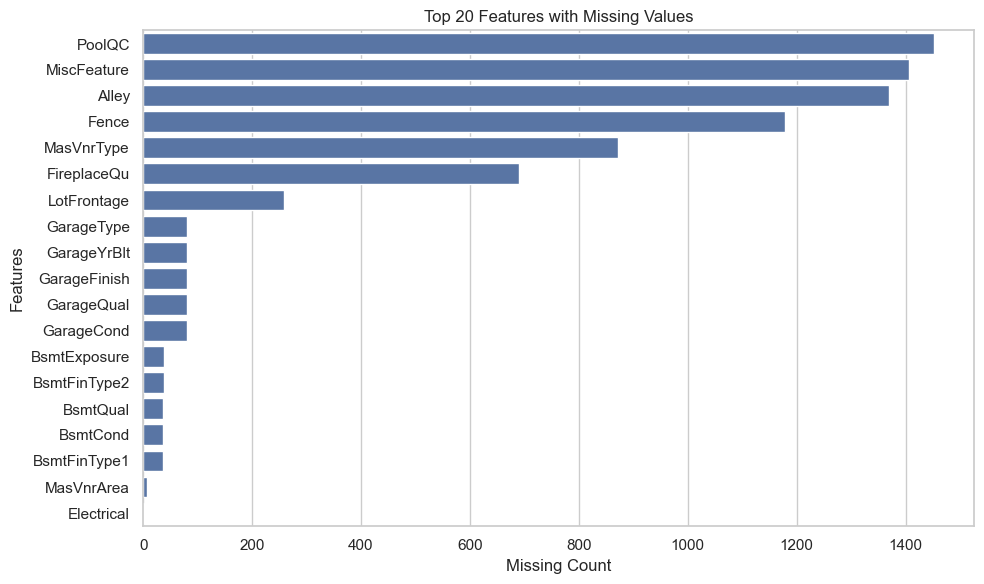

In [7]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(x=missing.values, y=missing.index)
plt.title("Top 20 Features with Missing Values")
plt.xlabel("Missing Count")
plt.ylabel("Features")
plt.tight_layout()
plt.savefig("../report/images/fig03_missing_values.png", dpi=300)
plt.show()

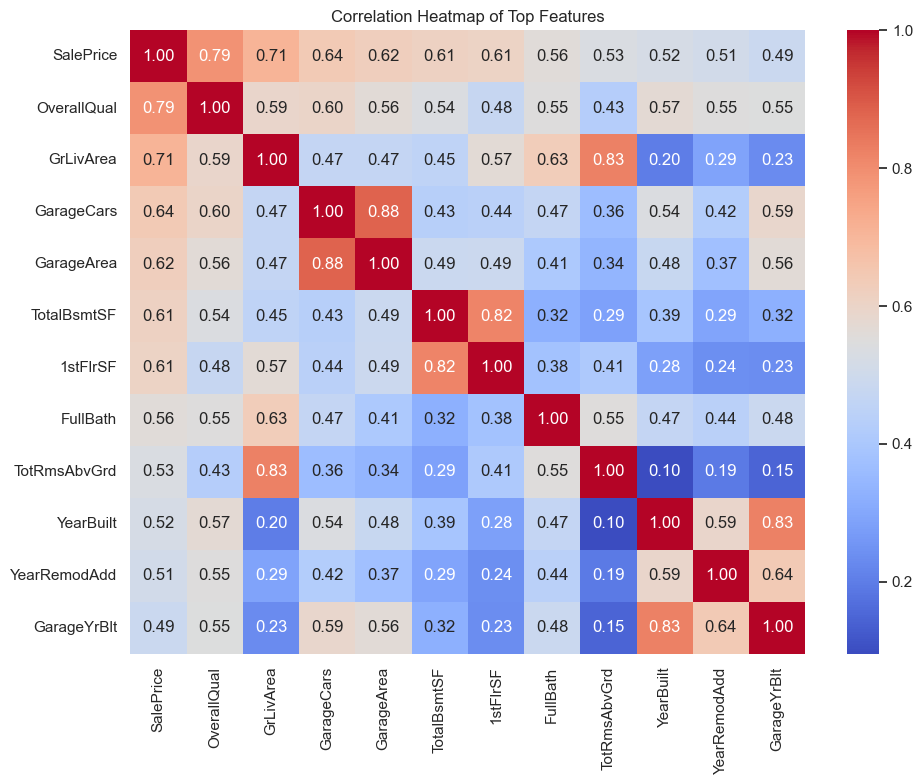

In [8]:
numeric_df = df.select_dtypes(include=["int64", "float64"])
corr = numeric_df.corr()

top_corr_features = corr["SalePrice"].abs().sort_values(ascending=False).head(12).index

plt.figure(figsize=(10, 8))
sns.heatmap(df[top_corr_features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Top Features")
plt.tight_layout()
plt.savefig("../report/images/fig04_correlation_heatmap.png", dpi=300)
plt.show()

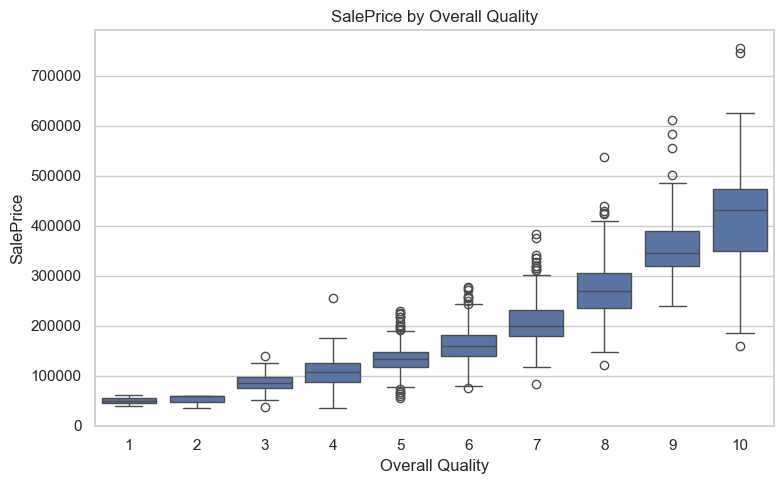

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="OverallQual", y="SalePrice", data=df)
plt.title("SalePrice by Overall Quality")
plt.xlabel("Overall Quality")
plt.ylabel("SalePrice")
plt.tight_layout()
plt.savefig("../report/images/fig05_overallqual_saleprice.png", dpi=300)
plt.show()

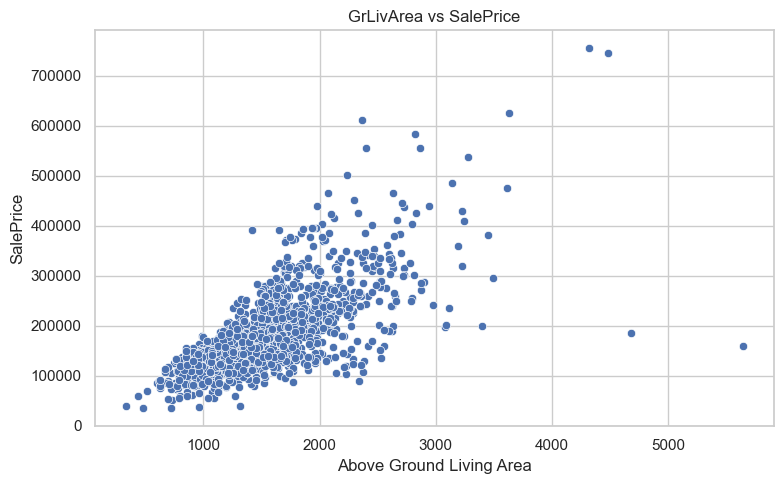

In [10]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="GrLivArea", y="SalePrice", data=df)
plt.title("GrLivArea vs SalePrice")
plt.xlabel("Above Ground Living Area")
plt.ylabel("SalePrice")
plt.tight_layout()
plt.savefig("../report/images/fig06_grlivarea_saleprice.png", dpi=300)
plt.show()

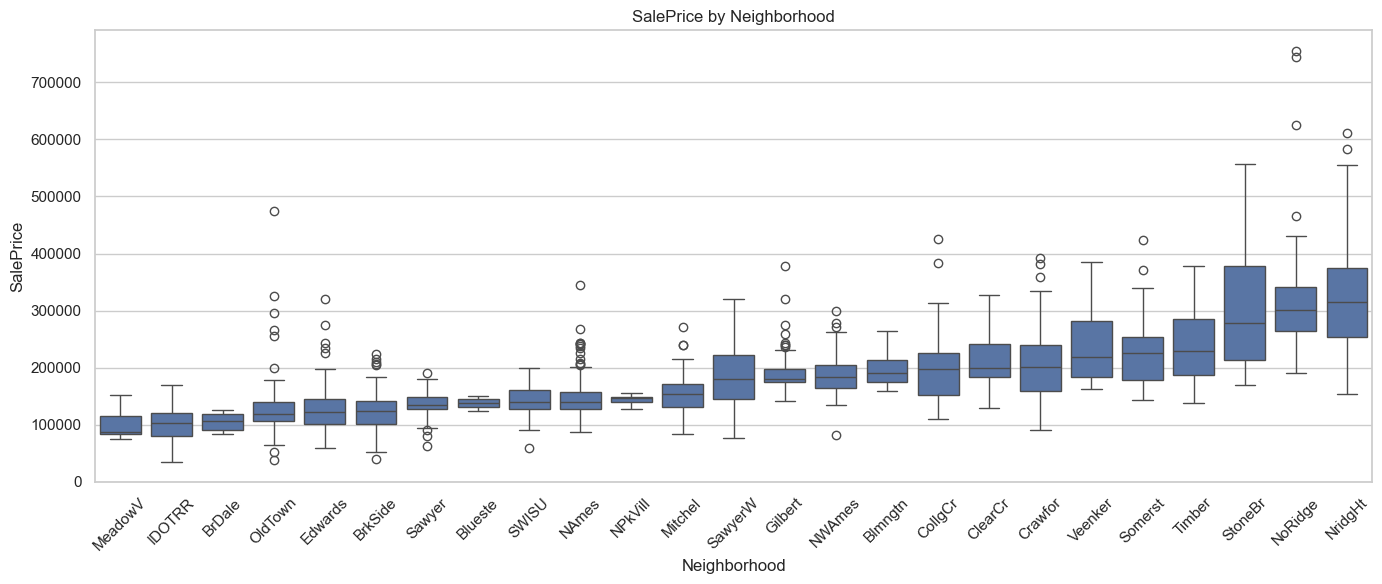

In [11]:
plt.figure(figsize=(14, 6))
order = df.groupby("Neighborhood")["SalePrice"].median().sort_values().index

sns.boxplot(x="Neighborhood", y="SalePrice", data=df, order=order)
plt.title("SalePrice by Neighborhood")
plt.xlabel("Neighborhood")
plt.ylabel("SalePrice")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../report/images/fig07_neighborhood_saleprice.png", dpi=300)
plt.show()

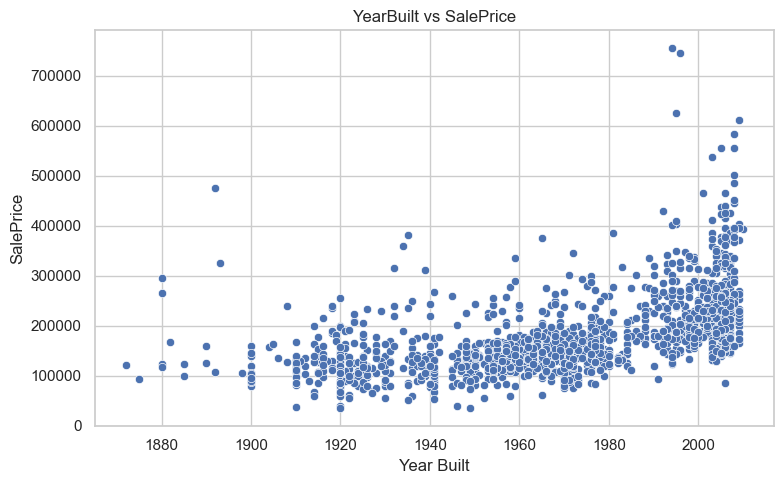

In [12]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x="YearBuilt", y="SalePrice", data=df)
plt.title("YearBuilt vs SalePrice")
plt.xlabel("Year Built")
plt.ylabel("SalePrice")
plt.tight_layout()
plt.savefig("../report/images/fig08_yearbuilt_saleprice.png", dpi=300)
plt.show()

In [13]:
missing_summary = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": df.isnull().sum() / len(df) * 100
}).sort_values("missing_percent", ascending=False)

missing_summary[missing_summary["missing_count"] > 0].head(20)

,missing_count,missing_percent
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageQual,81,5.547945
GarageFinish,81,5.547945
GarageType,81,5.547945


## Missing Value Analysis

Bảng trên thể hiện các cột có số lượng giá trị thiếu nhiều nhất trong bộ dữ liệu. Một số biến như `PoolQC`, `MiscFeature`, `Alley`, `Fence` có tỷ lệ missing values rất cao. Điều này cho thấy dữ liệu cần được xử lý trước khi đưa vào mô hình học máy.

Đối với các biến số, nhóm sử dụng giá trị trung vị (`median`) để thay thế missing values vì median ít bị ảnh hưởng bởi ngoại lệ. Đối với các biến phân loại, nhóm sử dụng giá trị xuất hiện nhiều nhất (`most_frequent`) để thay thế dữ liệu thiếu.

In [14]:
X = df.drop(columns=["SalePrice"])
y = df["SalePrice"]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Target shape:", y.shape)

Numerical features: 37
Categorical features: 43
Target shape: (1460,)


C:\Users\Nguyen Ba Thao\AppData\Local\Temp\ipykernel_24176\482244089.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


In [15]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [17]:
X_processed = preprocessor.fit_transform(X)

print("Original shape:", X.shape)
print("Processed shape:", X_processed.shape)

Original shape: (1460, 80)
Processed shape: (1460, 288)


In [18]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_valid shape:", X_valid.shape)
print("y_train shape:", y_train.shape)
print("y_valid shape:", y_valid.shape)

X_train shape: (1168, 80)
X_valid shape: (292, 80)
y_train shape: (1168,)
y_valid shape: (292,)


## Preprocessing Pipeline

Pipeline tiền xử lý được xây dựng bằng `scikit-learn` để xử lý đồng thời biến số và biến phân loại.

Đối với numerical features, nhóm sử dụng `SimpleImputer(strategy="median")` để thay thế missing values bằng trung vị, sau đó dùng `StandardScaler` để chuẩn hóa dữ liệu.

Đối với categorical features, nhóm sử dụng `SimpleImputer(strategy="most_frequent")` để thay thế missing values bằng giá trị xuất hiện nhiều nhất, sau đó dùng `OneHotEncoder(handle_unknown="ignore")` để mã hóa các biến phân loại.

Hai nhánh xử lý được kết hợp bằng `ColumnTransformer`, giúp quy trình tiền xử lý rõ ràng, dễ tái sử dụng và có thể tích hợp với mô hình học máy ở các bước tiếp theo.